# Week 8 Population Genomics

As we complete this workbook, please feel free to take notes and edit in the text boxes throughout.

## Mendelian vs Complex traits
![](https://drive.google.com/uc?export=view&id=1oTJuFSZqBJQY2d9YBRj5DkzyZ35hrAxo)

**Mendelian traits** can be predicted relatively simply using [Punnett squares](https://en.wikipedia.org/wiki/Punnett_square), taking into account modes of inheritence like recessive, dominant, sex-linked, and penetrance (more info in BICD 100). De novo mutations can also complicate these analyses.

These are the types of traits that 23andMe and similar services will predict for you. In my opinion, these only types of personal genomic results that are useful.


![](https://drive.google.com/uc?export=view&id=1ETN7HejT8Mt1zyA_JihsybwooaUwx4s9)


**Complex traits** depend on many genes are more difficult to analyze.

How can we identify genetic variants (SNPs) associated with a trait?

---




## Steps to perform a Genome-wide Association Studies (GWAS)

1. Collect (huge) cohorts of DNA samples and measure the trait (e.g. height) of each person.
2. Genotype each sample (person) using a genotyping array.
3. Test each SNP in the genome for association with the trait
4. Evaluate and interpret results

### 2. Genotyping

How can we detect and store genetic variants?

![SNP_genotyping_1](https://drive.google.com/uc?export=view&id=1YlziIdNVY5QDhU0vJJ0-bvwSpqY17Z2U)
Our genomes only vary at a few locations called Single Nucleotide Polymorphisms (SNPs or SNVs).

![SNP_genotyping_2](https://drive.google.com/uc?export=view&id=1bkDlmlbf5hevtGhhva_9NxzGLeuV6-iE)

We encode each variant as a *reference allele* or *alternate allele*. Reference allele's are the variants present on the human reference genome at that location. Nearly all locations only have 2 variants.

![SNP_genotyping_3](https://drive.google.com/uc?export=view&id=1QTxDhVfYNEbpaScBkA2yBriWWcNpvk31)

We finally count the number of times the alternate allele appears in that individual (0, 1, or 2) and generate a sequence that reresents that individuals genomic variants

![SNP_genotyping_4](https://drive.google.com/uc?export=view&id=1cGZhGYhTeBZpNcxLd7C_0Azg9KeyPfJ5)


SNPs and other small variants only account for 20% of nucleotides that vary. *Complex variations* account for the other 80%.

![](https://drive.google.com/uc?export=view&id=1PzGMvIkVQHwpicN68eaVNakaTFVWcSH6)

### 3. Test each SNP in the genome for association with the trait

![](https://drive.google.com/uc?export=view&id=1Ey0vR1RtcP16ISe-QbuAbAcTFGbU-NIL)

- $\beta$ values measure how strongly associated a variant is with a trait
- *p-values* measure the probability of seeing this result by random chance. With millions of SNPs to test, finding random associations is common. We use a much stricter p-value threshold to filter out noise.

---

![](https://drive.google.com/uc?export=view&id=1u1YWyWb9WMBHgQPNbytct-gG7UZhGtpH)

We typically plot the negative log(p-values) against their location in the genome to visualize this many associations.

---
This is called a *Manhattan Plot* due to the clusters of significant SNPs. Why might these clusters exist?

![](https://drive.google.com/uc?export=view&id=1fxqkE5mT6P4TqN42WuXe12Wa8II-4EDX)

## Let's try GWAS in practice

## Download Data and import packages

This data is from the [1000 genomes dataset](https://www.internationalgenome.org/). It is publically available, high-quality sequencing information from a few thousand genomes. We are downloading the dataset from the [UCSC genome browser](https://genome.ucsc.edu/) data portal.

The following cell also downloads [plink 1.9](https://www.cog-genomics.org/plink/1.9/) a common tool used to perform many types of population genomics analysis. [Hail](https://www.hail.is/docs/0.1/tutorials/hail-overview.html) is newer, likely faster tool, but we won't be covering it today.

In [ ]:
%%bash
wget https://s3.amazonaws.com/plink2-assets/alpha6/plink2_linux_avx2_20250129.zip
unzip plink2_linux_avx2_20250129.zip

wget -nv -O chr15.genotypes.vcf.gz https://hgdownload.cse.ucsc.edu/gbdb/hg19/1000Genomes/phase3/ALL.chr15.phase3_shapeit2_mvncall_integrated_v5a.20130502.genotypes.vcf.gz
wget -nv -O chr15.genotypes.vcf.gz.tbi https://hgdownload.cse.ucsc.edu/gbdb/hg19/1000Genomes/phase3/ALL.chr15.phase3_shapeit2_mvncall_integrated_v5a.20130502.genotypes.vcf.gz.tbi
wget -nv -O samples.ped http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/20130606_g1k_3202_samples_ped_population.txt

In [41]:
!pip install gdown

In [45]:
%%bash
gdown 1lK0KrlbbmDmB3-rXbKbK_EBRafSY3Ts1 -O igsr_samples.tsv

Downloading...
From: https://drive.google.com/uc?id=1lK0KrlbbmDmB3-rXbKbK_EBRafSY3Ts1
To: /content/igsr_samples.tsv
100%|██████████| 684k/684k [00:00<00:00, 103MB/s]


In [79]:
%%bash
# Check you imports to see if a help message appears
# The pipe `|` takes the output from one command and directs to the input of another command
# `head` truncates everything after the first 10 lines. We use it here to not clutter our space
./plink2 --help | head
echo
# You should see several files including chr15.genotypes.vcf.gz and chr15.genotypes.vcf.gz.tbi
ls

PLINK v2.0.0-a.6.9LM AVX2 Intel (29 Jan 2025)      cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3

In the command line flag definitions that follow,
  * <angle brackets> denote a required parameter, where the text between the
    angle brackets describes its nature.
  * ['square brackets + single-quotes'] denotes an optional modifier.  Use the
    EXACT text in the quotes.
  * [{bar|separated|braced|bracketed|values}] denotes a collection of mutually
    exclusive optional modifiers (again, the exact text must be used).  When

bcftools 1.13
Using htslib 1.13+ds
Copyright (C) 2021 Genome Research Ltd.
License Expat: The MIT/Expat license
This is free software: you are free to change and redistribute it.
There is NO WARRANTY, to the extent permitted by law.

chr15.genotypes.vcf.gz
chr15.genotypes.vcf.gz.tbi
filtered_genotypes.log
filtered_genotypes-temporary.pgen
filtered_genotypes-temporary.psam
filtered_genotypes-temporary.pva

The [vcf file specification](https://samtools.github.io/hts-specs/VCFv4.2.pdf) for reference.

**Ancestries as traits**

Data for GWAS studies can be difficult to acquire. There are some publically available genetic datasets, but none that also have associated phenotypes.

Large biobanks with trait and genomic data require special researcher access. Common biobanks used in the US include
- All of Us
- Million Veterans Program
- UK Biobank
- Commercial Databases (23andMe or ancestry.com)

We will use sample ancestry as our trait because it can be inferred from the genetic data itself. We first need to generate a phenotype file that for input into plink.

To read about the `pheno` file type we are generating refer to the [plink manual](https://www.google.com/url?q=https%3A%2F%2Fwww.cog-genomics.org%2Fplink%2F2.0%2Fformats).

In [106]:
import pandas as pd

def main():
    # Read the metadata; treat all columns as strings
    df = pd.read_csv('igsr_samples.tsv', sep='\t', dtype=str)

    # Drop rows with NA (or NaN) in Population or Superpopulation codes
    df = df.dropna(subset=['Population code', 'Superpopulation code'])

    # For Population code: split by comma if present, then "explode" to get one row per code.
    # This will make a sample with a value "IBS,MSL" appear as two rows.
    df['Population code'] = df['Population code'].str.split(',')
    df_exploded = df.explode('Population code')

    # Strip any extraneous whitespace from the codes
    df_exploded['Population code'] = df_exploded['Population code'].str.strip()

    df_exploded['Family id'] = 0
    df['Family id'] = 0

    # Write the phenotype file for population codes.
    # Using "Sample name" as both FamilyID and SampleID.
    df_exploded[['Family id', 'Sample name', 'Population code']].to_csv(
        'population.pheno', sep='\t', index=False, header=False)

    # For superpopulation codes, assume they are already clean (no combined values).
    df[['Family id', 'Sample name', 'Superpopulation code']].to_csv(
        'superpopulation.pheno', sep='\t', index=False, header=False)

    print("Created 'population.pheno' and 'superpopulation.pheno' files.")

if __name__ == "__main__":
    main()


Created 'population.pheno' and 'superpopulation.pheno' files.


In [107]:
%%bash
# Our files don't have the same samples so we have to filter them together
zcat chr15.genotypes.vcf.gz | grep -m 1 '^#CHROM' | cut -f 10- | tr '\t' '\n' \
  > sample_ids_from_genotypes.txt
cat population.pheno | cut -f2 > sample_ids_from_pheno.txt
grep -Fxf sample_ids_from_genotypes.txt sample_ids_from_pheno.txt | sort -u > overlap_ids.txt

In [108]:
%%bash
# Filter pheno files
awk 'NR==FNR {ids[$1]; next} $2 in ids' overlap_ids.txt population.pheno \
  > population_overlap.pheno
awk 'NR==FNR {ids[$1]; next} $2 in ids' overlap_ids.txt superpopulation.pheno \
  > superpopulation_overlap.pheno

Next we will actually perform the GWAS study. Note that we have several limitations.
- We have a small sample size
- We have several population groups

To fix this we are going to make our trait binary. Below is a function that takes as input a `.pheno` file and population name and generates a pheno file.

In [119]:
import pandas as pd

def make_binary_pheno(pheno_file, subgroup, trait_col=3, output_file=None):
    """
    Generate a binary phenotype DataFrame from an existing phenotype file.

    Parameters:
      pheno_file (str): Path to the input phenotype file. The file should be tab-delimited with no header.
                        Expected columns: [FamilyID, SampleID, trait, ...].
      subgroup (str): The target subgroup. Samples with a trait exactly equal to this value are set to 1; others 0.
      trait_col (int): 1-indexed column number of the trait to test. Default is 3.
      output_file (str, optional): If provided, the resulting DataFrame is written to this file.

    Returns:
      pd.DataFrame: A DataFrame with columns [FamilyID, SampleID, binary_pheno].
    """
    # Read the file with no header; treat all columns as strings.
    df = pd.read_csv(pheno_file, sep='\t', header=None, dtype=str)

    # Convert trait column to zero-indexed
    trait_idx = trait_col - 1

    # Create binary phenotype: 1 if trait matches subgroup exactly, otherwise 0.
    df['binary_pheno'] = df[trait_idx].apply(lambda x: 2 if x == subgroup else 1)

    # Select the first two columns (FamilyID, SampleID) and the new binary phenotype column.
    out_df = df[[0, 1, 'binary_pheno']]

    # If an output file is specified, write the result.
    if output_file:
        out_df.to_csv(output_file, sep='\t', index=False, header=False)

    #return out_df

make_binary_pheno("superpopulation.pheno", "EUR", trait_col=3,
                  output_file="EUR.pheno")


In the above cell we created a phenotype file for the European population where European samples our are cases and all other samples are our controls.

You can consider generating phenotype files for other cases too!

**Actually running GWAS**

The below command will actually run a GWAS statistical analysis. Start it now because it will take a while to run. Lets take a look at some of the parameters:

- `vcf` contains our input genotype information. Note that we can give the compressed vcf file as input.
- `const-fid` this sets the family id to constant 0. Family ids are used to identify our samples but they are not present in our phenotype files so we use a default value
- `pheno` contains our phenotype file of default family id, sample ids, and corresponding control/case (1 or 2 in third column).
- `glm` Generalized linear model. This is the actual GWAS function. We might it need the parameter `allow-no-covars`
- `threads` Allows a bit of parallelization
- `out` gives header for output files

In [121]:
%%bash
# GWAS for the Population trait
time ./plink2 \
  --vcf chr15.genotypes.vcf.gz \
  --const-fid 0 \
  --pheno EUR.pheno \
  --glm allow-no-covars \
  --threads 2 \
  --out gwas_EUR


PLINK v2.0.0-a.6.9LM AVX2 Intel (29 Jan 2025)      cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to gwas_population.log.
Options in effect:
  --const-fid 0
  --glm allow-no-covars
  --out gwas_population
  --pheno european.pheno
  --threads 2
  --vcf chr15.genotypes.vcf.gz

Start time: Fri Feb 28 00:37:40 2025
12978 MiB RAM detected, ~11812 available; reserving 6489 MiB for main
workspace.
Using up to 2 compute threads.
--vcf: 2424689 variants scanned.
--vcf: gwas_population-temporary.pgen + gwas_population-temporary.pvar.zst +
gwas_population-temporary.psam written.
2504 samples (0 females, 0 males, 2504 ambiguous; 2504 founders) loaded from
gwas_population-temporary.psam.
2424689 variants loaded from gwas_population-temporary.pvar.zst.
1 binary phenotype loaded (502 cases, 2002 controls).
Calculating allele frequencies... 0%2%5%8%10%13%16%18%21%24%27%29%32%35%37%40%43%4


real	20m50.268s
user	25m29.149s
sys	0m40.994s


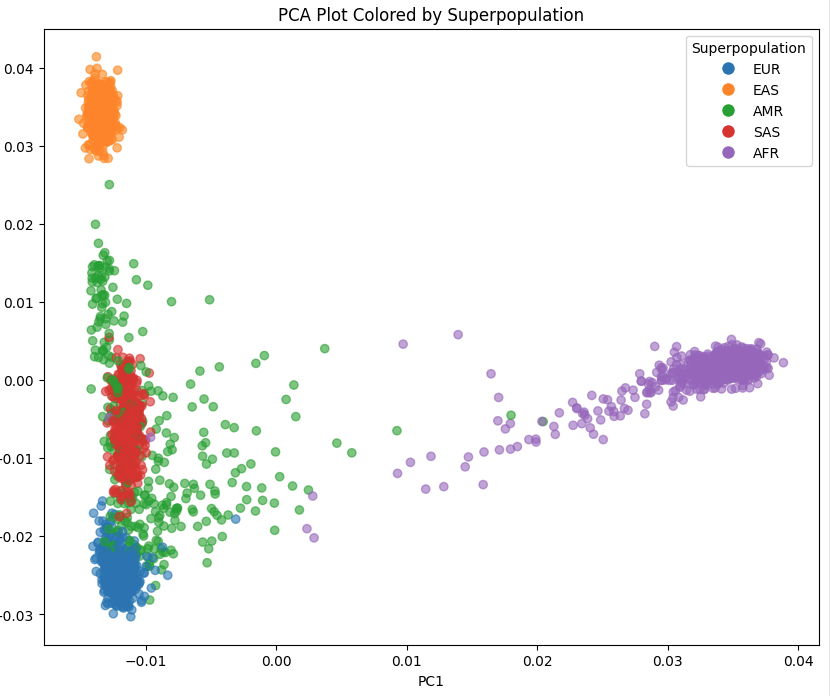

Finally lets generate a manhattan plot for our completed GWAS study

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_manhattan(filename, title):
    # Load the GWAS results; adjust delim_whitespace if needed
    df = pd.read_csv(filename, delim_whitespace=True)

    # Filter out rows with missing p-values and convert to numeric type
    df = df[df['P'] != 'NA']
    df['P'] = pd.to_numeric(df['P'], errors='coerce')

    # Calculate the -log10(p-value)
    df['minus_log10_p'] = -np.log10(df['P'])

    # Create the Manhattan plot for a single chromosome (chr15)
    plt.figure(figsize=(10,6))
    plt.scatter(df['POS'], df['minus_log10_p'], c='blue', s=10)
    plt.xlabel('Genomic Position')
    plt.ylabel('-log10(p-value)')
    plt.title(title)

    # Optional: Draw a genome-wide significance line (e.g., at p = 5e-8)
    plt.axhline(y=-np.log10(5e-8), color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

# Plot for Population trait GWAS
plot_manhattan("gwas_EUR.PHENO1.glm.logistic.hybrid", "Manhattan Plot for EUR samples")


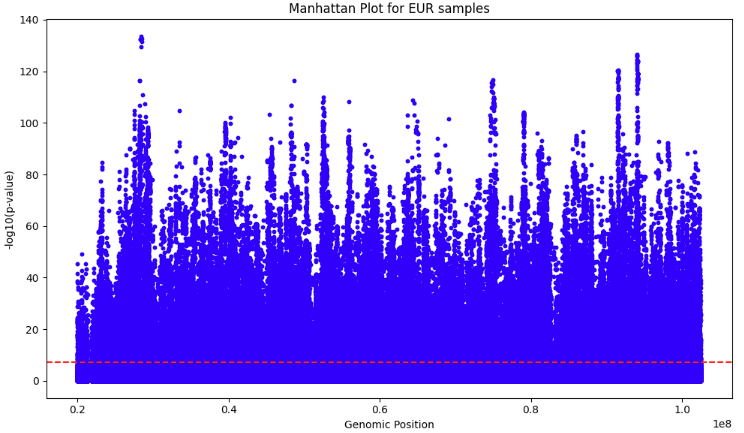

## Detour: What does it mean for a trait to be heritable?

Heritability roughly describes how much variation in a trait is inherited (i.e. due to genetics). Offspring tend to look like their parents.

Your phenotype ($P$) is the sum of effects of your genetics ($G$) and your environment ($E$):

$$P = G + E$$

Looking at a _population_, we're interested in phenotypic **variance**:
$$V_p = V_G + V_E + V_{GE}$$

_Heritability_ describes how much variation in the phenotype is described by genetics:
$$h^2 = \frac{V_G}{V_P}$$

---

Heritability of example traits:
- Height: 80%
- Breast cancer: 30%
- Type 1 Diabetes: 90%
- Type 2 Diabetes: 30-60%
- Obesity: 40-60%
- Schizophrenia: 70-80%
- Platelet count: 80%
- HDL cholesterol: 50%


Heavily sourced from CSE 185 and CSE 284, courses by Professor Gymrek.

There are many ways to measure heritability (and they don't always give the same results!)

**1. Midparent Method**
![](https://drive.google.com/uc?export=view&id=1izlQFsyyt0b-kmckcvTp48HfwMYIh29v)
Where $Y_{mid}$ is the average value of both parents and $\epsilon$ is the effect of randomness.

---

**2. Twin Studies**

Let $r$ be the correlation level of a trait between twins.
Identical (monozygotic) twins share:
- 100% of genomes
- A lot of environmental factors
$$r_{MZ} = V_G + V_E$$

Fraternal (dizygotic) twins share:
- 50% of their genomes (on average)
- A similar amount of environmental factors
$$r_{DZ} = \frac{1}{2}V_G + V_E$$

Therefore
$$2(r_{MZ} - r_{DZ}) = 2V_G + 2V_E - V_G - 2V_E = V_G$$
and
$$h^2 = 2(r_{MZ} - r_{DZ})$$

Another estimate of heritability!

But monozygotic twins tend to share more environmental factors than dizygotic twins. Dizyogtic twins share on average 50% of their genomes. Sometimes more, sometimes less.

---
**Other Methods:**
- Haseman-Elston Regression
- **Linear mixed models**
- LD-score regression




The first two methods we discussed require individuals from the same family to estimate heritability of traits.

We can also estimate heritability of traits in a population a Linear Mixed Model (LMM) used for a GWAS study.

**Brief Linear Mixed Model summary:**
We estimate a trait, $Y$, as the sum of a genetic component, $u$, and an environmental component, $\epsilon$. This is a type of GWAS study.
$$ Y = u + \epsilon$$

Then we estimate the variance from the genetic component over the total amount of variance. Something like, but not exactly:
$$h^2 = \frac{Var(u)}{Var(u) + Var(\epsilon)}$$

---

This measure of heritability is often significantly lower than the family/pedigree based methods. Heritability from only GWAS hits is even lower than heritability from all GWAS SNPs.

Why?

![](https://drive.google.com/uc?export=view&id=1HQM7-TOro_g3SXop3bZc15rgjXeb3_iw)

This problem is called the _[heritability gap](https://en.wikipedia.org/wiki/Missing_heritability_problem)_.

What does this mean for GWAS results?
- Relying on only significant SNPs is not enough to determine an individuals risk for a disease. Even polygenic risk scores, using all GWAS SNPs, are often not sufficient (especialy when predicting outside of the training population).

